## 1-imports

In [17]:
#%pip install --upgrade plotly nbformat ipython jupyter
! pip install matplotlib


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 764.3 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/8.1 MB 764.3 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.1 MB 745.8 kB/s eta 0:00:10
   ----- ---------------------------------- 1.0/8.1 MB 868.0 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.1 MB 868.0 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.1 MB 818.6 kB/s eta 0:00:09
   ------- -------------------------------- 1.6/8.1 MB 847.3 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.1 MB 847.3 kB/s eta 0:00:08
   --------- ------------------------------ 1.8/8.1 MB 832.2 kB/s eta 0:00:08
   ---------- --------

In [20]:
import sys
!{sys.executable} -m pip install seaborn


In [21]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

## 2-Data loading and understanding

In [22]:
df=pd.read_csv('Udemy Courses.csv')
df.head()

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12T19:06:34Z,Musical Instruments
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26T18:34:57Z,Musical Instruments
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21T23:48:18Z,Musical Instruments
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21T23:44:49Z,Musical Instruments


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   course_id            3682 non-null   int64 
 1   course_title         3682 non-null   object
 2   is_paid              3682 non-null   bool  
 3   price                3682 non-null   object
 4   num_subscribers      3682 non-null   int64 
 5   num_reviews          3682 non-null   int64 
 6   num_lectures         3682 non-null   int64 
 7   level                3682 non-null   object
 8   content_duration     3682 non-null   object
 9   published_timestamp  3682 non-null   object
 10  subject              3682 non-null   object
dtypes: bool(1), int64(4), object(6)
memory usage: 291.4+ KB


In [ ]:
df.isna().sum()
df.isna().mean() * 100


course_id              0.0
course_title           0.0
is_paid                0.0
price                  0.0
num_subscribers        0.0
num_reviews            0.0
num_lectures           0.0
level                  0.0
content_duration       0.0
published_timestamp    0.0
subject                0.0
dtype: float64

In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


## EDA

## Univariate analysis

In [23]:
for col in df.columns:
    if col =='course_title' or col=='course_id':
        continue
    else:
        fig = px.histogram(data_frame= df, x= col,color_discrete_sequence=["#279339"] ,title= col)
        fig.show()

## Bivariate analysis

### 1-Diffrent courses subjects and the udemy coverage

In [24]:
subject=df['subject'].unique().tolist()
subject

['Musical Instruments',
 'Business Finance',
 'Graphic Design',
 'Web Development']

In [25]:
subject_courses=df.groupby('subject')['course_id'].count().sort_values(ascending=True).reset_index()
subject_courses=subject_courses.rename(columns={'course_id':'course_count'})
subject_courses

,subject,course_count
0,Graphic Design,603
1,Musical Instruments,680
2,Business Finance,1199
3,Web Development,1200


<Axes: xlabel='subject', ylabel='course_count'>

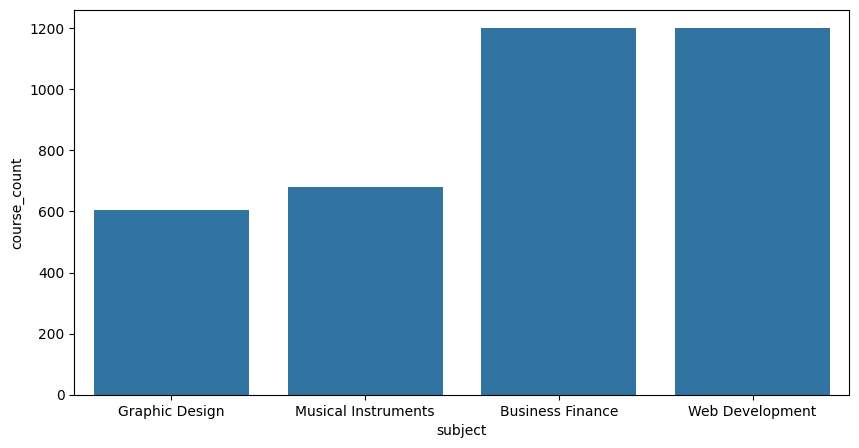

In [26]:
plt.figure(figsize = (10 , 5))
sns.barplot(data=subject_courses,x='subject',y='course_count')

In [ ]:
px.bar(
    subject_courses,
    x='subject',
    y='course_count',
    text_auto=True,
    title='Number of Courses per Subject'
)


### 2-Free courses vs paid courses in udemy

In [ ]:
free_courses=df[df['is_paid'] == False]
paid_courses=df[df['is_paid'] == True]
free_courses.head()

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
41,286070,5 lecciones que todo guitarrista debe tomar,False,Free,4452,263,14,Beginner Level,1 hour,2014-08-23T05:08:14Z,Musical Instruments
49,696630,"7 Ways A Beginner Guitarist Can Sound Better, ...",False,Free,4529,193,7,Beginner Level,36 mins,2015-12-21T18:50:50Z,Musical Instruments
57,955914,A beginner`s guide to fingerpicking and strumm...,False,Free,3481,29,20,Beginner Level,2 hours,2016-09-13T21:51:59Z,Musical Instruments
67,270976,A how to guide in HTML,False,Free,7318,205,8,Beginner Level,35 mins,2014-08-10T20:19:10Z,Web Development
74,1214144,¡Triunfar en La Bolsa de Valores No Requiere d...,False,Free,338,7,6,Beginner Level,1 hour,2017-05-30T14:30:12Z,Business Finance


In [ ]:
free_vs_paid=df.groupby('is_paid')['course_id'].count().reset_index()
free_vs_paid=free_vs_paid.rename(columns={'is_paid':'is_the_course_paid?','course_id':'Number_of_courses'})
free_vs_paid

,is_the_course_paid?,Number_of_courses
0,False,310
1,True,3366


<Axes: xlabel='is_the_course_paid?', ylabel='Number_of_courses'>

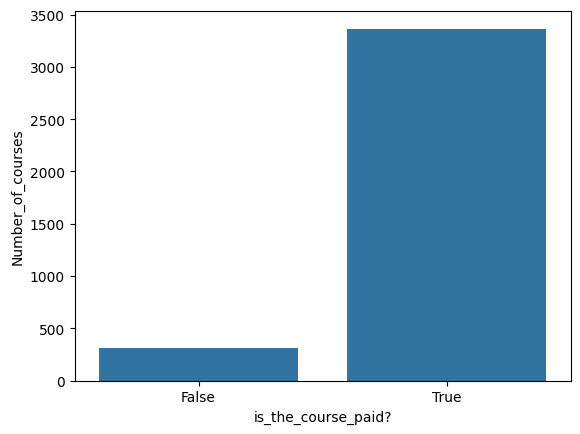

In [ ]:
plt.Figure(figsize=(10,5))
sns.barplot(data=free_vs_paid,x='is_the_course_paid?',y='Number_of_courses')

In [ ]:
px.bar(data_frame=free_vs_paid,
       x='is_the_course_paid?',
       y='Number_of_courses',
       title='free VS Paid')

### 3-TOP courses vs worst courses across subjects

In [ ]:
df.head(1)

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments


In [ ]:
most_famous_course=df.sort_values(by='num_subscribers',ascending=False).head(1).iloc[0]['course_title']
type(most_famous_course)

str

In [ ]:
top_7=(df.sort_values(by='num_subscribers',ascending=False).head(7))
top_7 = top_7.reset_index(drop=True)
top_7['subject']

0        Web Development
1        Web Development
2        Web Development
3        Web Development
4        Web Development
5    Musical Instruments
6        Web Development
Name: subject, dtype: object

<Axes: title={'center': 'Top 7 Most Subscribed Courses'}, xlabel='Number of Subscribers', ylabel='Course Title'>

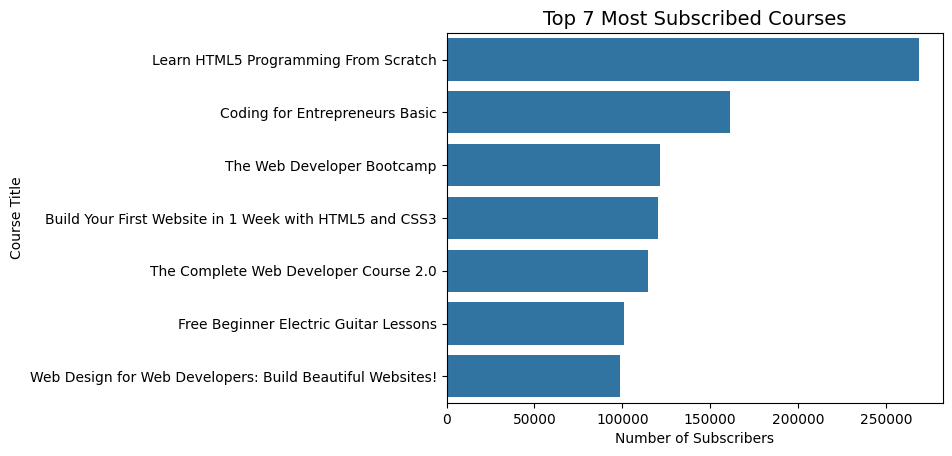

In [ ]:
fig=plt.Figure(figsize=(7,7))
fig=sns.barplot(data=top_7,y='course_title',x='num_subscribers')
plt.title('Top 7 Most Subscribed Courses', fontsize=14)
plt.xlabel('Number of Subscribers')
plt.ylabel('Course Title')
fig

In [ ]:
px.bar(data_frame=top_7,
       y='course_title',
       x='num_subscribers',
       color_discrete_sequence=['#1f77b4'],
       #color_discrete_sequence=px.colors.qualitative.Set2,
       title='TOP 7 courses')

In [1]:
worst_7=(df.sort_values(by='num_subscribers',ascending=True).head(7))
worst_7 = worst_7.reset_index(drop=True)
px.bar(data_frame=worst_7,
       y='course_title',
       x='num_subscribers',
       color_discrete_sequence=['#1f77b4'],
       title='worst 7 courses')

NameError: name 'df' is not defined

### 4-Cheap courses vs expensive courses

In [ ]:
df['price'] = df['price'].apply(lambda x : '0' if x == 'Free' else x)
df['price'] = pd.to_numeric(df['price'] , errors = 'coerce')


In [ ]:
cheap_courses = df[df['price'] <= 100]
expensive_courses = df[df['price'] > 100]
cheap_mean = cheap_courses.groupby('subject')['price'].mean()
cheap_count = cheap_courses.groupby('subject')['course_id'].count()
expensive_mean = expensive_courses.groupby('subject')['price'].mean()
expensive_count = expensive_courses.groupby('subject')['course_id'].count()


In [ ]:
price_summary = pd.DataFrame({
    'cheap_course_count': cheap_count,
    'cheap_avg_price': cheap_mean,
    'expensive_course_count': expensive_count,
    'expensive_avg_price': expensive_mean
}).reset_index()
price_summary

,subject,cheap_course_count,cheap_avg_price,expensive_course_count,expensive_avg_price
0,Business Finance,929,37.346609,266,177.593985
1,Graphic Design,507,36.035503,95,174.526316
2,Musical Instruments,631,40.293185,49,168.877551
3,Web Development,886,42.336343,313,175.255591


In [ ]:
px.pie(data_frame=price_summary,names='subject',values='cheap_course_count',title='cheap courses by percentage')


In [ ]:
px.pie(data_frame=price_summary,names='subject',values='cheap_avg_price',title='cheap courses average price')


In [ ]:
px.pie(data_frame=price_summary,names='subject',values='expensive_course_count',title='expensive courses numbers')


In [ ]:
px.pie(data_frame=price_summary,names='subject',values='expensive_avg_price',title='expensive courses average price')


### 5-can we find the python courses?

In [ ]:
python_courses=df[ df['course_title'].str.contains('Python')]
python_courses.head()

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
216,599504,Advanced Scalable Python Web Development Using...,True,120,1299,56,71,Intermediate Level,14 hours,2016-08-11T22:09:24Z,Web Development
777,47963,"Coding for Entrepreneurs: Learn Python, Django...",True,195,23412,799,251,All Levels,45 hours,2013-04-08T00:46:14Z,Web Development
814,631128,Complete Python Web Course: Build 8 Python Web...,True,110,7489,941,173,All Levels,16 hours,2015-11-08T20:57:35Z,Web Development
842,186096,"Core: A Web App Reference Guide for Django, Py...",True,195,2497,98,154,All Levels,26 hours,2014-05-29T00:58:43Z,Web Development
1400,394832,Fun and creative web engineering with Python a...,False,0,10917,319,25,All Levels,2 hours,2015-06-09T19:51:50Z,Web Development


### 6-Can we find all the courses released in 2015?

In [ ]:
df['published_timestamp'] = pd.to_datetime(df['published_timestamp'])
df['year'] = df['published_timestamp'].dt.year
by_year=df[df['year'] == 2012]['course_title'].to_frame()
by_year

,course_title
130,Accounting Skills for Managers
207,Advanced HTML5 Tutorial for Web Developers
241,AJAX Development
353,Aprende a Tocar Teclado - Piano
355,Aprende batería con el nuevo método IDT
461,Beginner Guitar Method
464,Beginner Photoshop to HTML5 and CSS3
782,Color Basics for Print Designers
904,Create an Engaging Website with Twitter Bootst...
972,CSS Development (with CSS3!)


### 7-customers level by subscription in courses

In [ ]:
peak_pop_per_level=df.groupby('level')['num_subscribers'].sum().reset_index()

peak_pop_per_level

,level,num_subscribers
0,All Levels,6872827
1,Beginner Level,4052843
2,Expert Level,50196
3,Intermediate Level,742005


In [ ]:
px.pie(data_frame=peak_pop_per_level,
       names='level',
       values='num_subscribers',
       color_discrete_sequence=["#b3b7ae"],
       title='number of subscribers per level')

# Deployment

In [ ]:

%%writefile udemy.py
import streamlit as st
import pandas as pd
import plotly.express as px


# ---------------- Page Config ----------------
st.set_page_config(
    page_title="Udemy Analysis Dashboard",
    layout="wide"
)

st.title(" Udemy Analysis Dashboard")
st.image('data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAUcAAACaCAMAAAANQHocAAAAw1BMVEXy8/UAAAD19vikNfDk5ebw8fMfIB+Wl5j4+fvo6evt7vCjpKXh4uTz9fXP0NIRERFUVVZhYWInJidbW1toaGkuLi/0+PWiL/Dw7PXV1tfb3N7Rp/K8vb6gJ/CqRPDKy81FRUZNTk65urs8PD3OnfLu6fWpqqt3eHk+Pj+Njo9JSUoYGBjk0PTFh/Lr4vWoPfDn2PSsR/C6bPF+f4DXsvO2YPHhyPS9dPGvUfDIjvK3Y/HjzvTFhfLfxPSyWfHcvfTQofNvS0wlAAAJXklEQVR4nO2caWOaSBiAYQJyCKKCNVB2UexC1LZJa+/tdvf//6plgLk4IolJRnff55uTEYaHOd45jKIAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAI/rurKL8F/Avb67BpGn4ipv331491YBkyfhvn/zYblcfnjzHkQ+Gtf949Pn5fLq6mq5/PXpGrrJx+HqX75eYYuY5dXXP3UQ+XBc9+27W2KxNHn7/Q6q5EMpOsZvvMXS5LfXf4DIB+C+uv7066qpETfuH9BNDkfoGJsmv36BGGgY7vvvYse4bHaTskt4Gbx6/Ztg8cebH6LJzzC/GYLgcfmtCMFxMM4l/Q4eh8B5XN6+uyu6Q9f98ydr6kM8opqXKO+5Qj0urz7+Vcfe7vVfH8nQM8CjE1ZEz1/a86X2uFx+5oKcYo74+lfVTR73aOdqxUJ79tKeL5VHvDbxSkh376pucoDHoPY40v7HLRt7XN7+bK+Vucrbn0XjBo/DwB4//t01b3Hd678/gseBvHqN59Hdqspu8hY8DsG9u7vPk3v3D3gcxv2ajgfh4PFpAI9PA3h8GsDj0wAeH4u4LHGfR4SGrmF0Zrqk5Q9kVjSLS9LNZjqytWiSJGGk6eUz9npEihUlmWEY4zis8/ZcHiHLicLiigqXqU4MHYum0i91uu0r8YuAJuOKWEzX4zo904XsbjIONqU2b5VnYVFdejwiK95OvfpP6uaQipbJbTNsKTFm8/KKh9SucyE73s7KG43Wh9iqUqMxKWyHSJSQS8pYLzG39ZOuxXR7ShRYLBHp8WykciyCRNG7PCIrW6siq7HFPb1BkkMzzPcsl5/gTMgWvz4t3zKakIw3HV2xtSPlmEjoCkzyQFMx3fbrdI95RFGuNvEOYYdHlPitnMRRBfMYL4RMowwLmzVvY+BmodP7Z+2+NCV/m9nP4OkYD/CIkpsOOeoNSeU8jvddOdV5Rq9Pbuttm1m91EwXzW+q6hYXlroKWq5os1BTGSPTcI8oFZp0G+IR2du+LB4VSeuj18q0Gc+7vouroEXemddsuygk72MtozoO94jS9hN3e1R6NarqnlQWoz9PDxsHKYh+bdv0SG86lhIoDfWIko621ukRZXyiN18s+Hq8qCvSwz2qW7OodaSq3lhCcZG2IjeIztkj0qb8Iy2ms8Bviq08opBL9404dKIiVGJJ9SggePTWee63qvt+mudTLnWF45kD+ZQJYSJ7eQc5cfvQ+si1VS+II8u2iyD7IPSYlUfW36vr1DLLGYlpx2uaWg21vMcg0XTdmojBgLcNLaVI5V5BETWimIgVRxqbDPB7GUGPMtQja09Fi0qVam5SCBLik9IjSmgNyh0unnRozl2pm/O4tcvrIf3AXWyfVbMYZDO9RpFikyhREIYmJM/suYX1MMyjyarjmu9/kMU9e1Uf6WMfbL5mII1GlKnoMaBTGGvNLmbQuaBDej41L6ogGlP9fDloMaQEPcpAj9yz7MRuHNlMJPaIItI7rpuz7Qltkfgj9Thn9cpkI9SKfZuWUF3hotAbbLiw39mQ4slacxrmMSaP4jVntkijlaj0SCPlrLlcQCcjC1zDqZyAb/w0Jt+yb7PIcFFK6hhpTFpJDUkaB7Zr2qyD1gWYubJdk6eca2YTUtvKGJp65J/cphOmhE8llW2OO9yukcYihZUU9CgDPep+1/ORnCQiwh518mE/C2YiARkh1LHJeeQrOL2P5/Cpa96jYpOPdKRBCblYLm2xcpBHWiMWHd0PnWNgj/bRaF2tGi1bp+CNkUF9zt+HvpvKIwsVt6QEtKl3vOYXYpBHjcSJXUsptPPEHq3uBQqRw1GPi/s8auRdLeqpVkSCsvbqxYsxxCOKSJeU6+0roGRPPSLn2CT8dI9cb12NNGxAb6+mvRiDPIbEzqHT44h5jF7AI31xalAWh4adK1lBj3KZ9ZGWbZ8gPiiTFvQoAz06g/tHjfaPXj/GiR4bIw2Zgc+lBT1Kv0eLFL4crxddz1cjjteky/eTSS943eYkjxpXHhamH55Bz2Cox5WYzlaeHxY/rusPOxv1gr91ikd+pEF06t+aar0o1OOcD325pjw6Np+h3VM5n6HLFEfWr07yyI00SCPhvS8v6FH4oCHlJ8SsC9rY98+v2SJNOb9m66n3b8efVh9pnzhK2IRe6sEL5pEfQxDtHlVfF9d7hGorLA+WHkNSj+etLkA4YnKaR7YytCVf2UgMehTeYzntrWH7SapR5mLrj/79649sOXwqGi8UZw67w4n10aJrF0I55cGWa1RvXB3CQUg3WBhYnW8I2Q4Ctx6utNfD2Raz6k+4CoiUdKPuUp2knOgRNfck55L2E2iBtA0rTJA4xQM7Mbcnsrba5cb7M7puR8lBmE3X+zNM7XwcKeUGjWlaSVDfwW3sFz7S46SxmS5vpYeUSNi52wU5W9/C1I2dW67FbPwg8DeqSL1fmHC7+JvcSOMkztiJqdEheoK4R+ECgwp5Kz01yOk8bUK8kgdCcechh7ZHbgelopjACJ+rN3OqR67/wMg5RCGA4v61rhF7zU9zngJvf5V5Tq6PlvD65QY9NY0KxNjzxUPZkbVF6rH/fI/qGfaT9I+N/mjlnINHpcfQXNzERHGzR6yegcSW7LyZnvV0Aht6xdM9ciEEvy0mlUQ4dVIza5/pap9/VPPu849BO6e6P7DY82SP3GFIdRSeRXXE8fRYGKULppndKhw+jyuGOkHMIm+PP49rx0EjMlnkCXf8u9sjWQ+Z80eT6drHXvDIjTTtWb80TC097Iij0XobW52vGOmJEVSrVt4mGCc4rqYnyW0x52Qc3NRj0746S879mZwPHwvnxrov1Z2qWHSyKnWlpwEqf16QFsVNk8hWekuGkG2FSRwnoWXTcz6dP9DAOaMkTosIsojbm3/u/FL3pXpS6ckKXzzDJ5+hv3YZ/ruWZ/wXIGzAHp/JKHORsBnW4jyCnguFLbA0jzgDD4FtxJ1L0HORsJXcXP7U+nIxJ2RuJXd764LBw78e09hx1nE0ATiOlfu+v2NrT1AdHwVyxJOB0Ds+DnYUvIodYbB+HKJHT9bPEy4e0aPkzdYLhvdY/SgbeAzcOLODRn0Czno/Go3mN0Eq9yDKpaOHSUFoXcw/pDlXLumf+gAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAADyUfwFc1K+OUCY/VQAAAABJRU5ErkJggg==')
# ---------------- Data Loading ----------------


df = pd.read_csv("Udemy Courses.csv")

# ---------------- Sidebar ----------------
analysis_section = st.sidebar.radio(
    "Select Analysis",
    options=[
        "Full Dataset",
        'Univariate Analysis',
        "Number of Courses per Subject",
        "free vs paid",
        "Top 7 most famous courses",
        "Pricing Analysis",
        "customers profesional level"
    ]
)

# ---------------- Main Content ----------------
st.subheader(analysis_section)

if analysis_section == "Full Dataset":
    st.write(f"Complete dataset ({df.shape[0]} rows)")
    st.dataframe(df)

elif analysis_section== 'Univariate Analysis':

    st.title('Univariate Analysis')

    for col in df.columns:
        if col =='course_title' or col =='course_id':
            continue

        st.plotly_chart(px.histogram(data_frame= df, x= col, title= f'the distrbution of {col}'))


elif analysis_section == "Number of Courses per Subject":
    st.write("Number of Courses per Subject (bivariate Analysis)")
    
    subject_courses =df.groupby('subject', as_index=False)['course_id'].count().sort_values(by='course_id', ascending=True)
    subject_courses=subject_courses.rename(columns={'course_id': 'course_count'})


    fig1 = px.bar(
        subject_courses,
        x='subject',
        y='course_count',
        text_auto=True,
        title='Number of Courses per Subject'
    )

    st.plotly_chart(fig1, use_container_width=True)

elif analysis_section == "free vs paid":
    st.write("free vs paid  (bivariate Analysis)")
    free_vs_paid=df.groupby('is_paid',as_index=False)['course_id'].count()
    free_vs_paid=free_vs_paid.rename(columns={'is_paid':'is_the_course_paid?','course_id':'Number_of_courses'})
    fig2=px.bar(data_frame=free_vs_paid,
       x='is_the_course_paid?',
       y='Number_of_courses',
       title='free VS Paid')
    st.plotly_chart(fig2, use_container_width=True)

elif analysis_section == "Top 7 most famous courses":
    st.write("Top 7 most famous courses  (bivariate Analysis)")
    top_7=(df.sort_values(by='num_subscribers',ascending=False).head(7))
    top_7 = top_7.reset_index(drop=True)
    fig3=px.bar(data_frame=top_7,
       y='course_title',
       x='num_subscribers',
       color_discrete_sequence=['#1f77b4'],
       #color_discrete_sequence=px.colors.qualitative.Set2,
       title='TOP 7 courses')
    st.plotly_chart(fig3, use_container_width=True)

elif analysis_section == "Pricing Analysis":
    st.write("Pricing analysis")
    df['price'] = df['price'].apply(lambda x : '0' if x == 'Free' else x)
    df['price'] = pd.to_numeric(df['price'] , errors = 'coerce')
    cheap_courses = df[df['price'] <= 100]
    expensive_courses = df[df['price'] > 100]
    cheap_mean = cheap_courses.groupby('subject')['price'].mean()
    cheap_count = cheap_courses.groupby('subject')['course_id'].count()
    expensive_mean = expensive_courses.groupby('subject')['price'].mean()
    expensive_count = expensive_courses.groupby('subject')['course_id'].count()
    price_summary = pd.DataFrame({
    'cheap_course_count': cheap_count,
    'cheap_avg_price': cheap_mean,
    'expensive_course_count': expensive_count,
    'expensive_avg_price': expensive_mean
    }).reset_index()
    st.dataframe(price_summary)




elif analysis_section == "customers profesional level":
    st.write("customers profesional level  (bivariate Analysis)")
    peak_pop_per_level=df.groupby('level',as_index=False)['num_subscribers'].sum()
    fig4=px.pie(data_frame=peak_pop_per_level,
       names='level',
       values='num_subscribers',
       color_discrete_sequence=["#b3b7ae"],
       title='number of subscribers per level')
    st.plotly_chart(fig4, use_container_width=True)
    
    


Overwriting udemy.py


In [ ]:
!streamlit run udemy.py

^C
